## 1. The most Nobel of Prizes
<p><img style="float: right;margin:5px 20px 5px 1px; max-width:250px" src="https://assets.datacamp.com/production/project_441/img/Nobel_Prize.png"></p>
<p>The Nobel Prize is perhaps the world's most well known scientific award. Except for the honor, prestige and substantial prize money the recipient also gets a gold medal showing Alfred Nobel (1833 - 1896) who established the prize. Every year it's given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace. The first Nobel Prize was handed out in 1901, and at that time the Prize was very Eurocentric and male-focused, but nowadays it's not biased in any way whatsoever. Surely. Right?</p>
<p>Well, we're going to find out! The Nobel Foundation has made a dataset available of all prize winners from the start of the prize, in 1901, to 2016. Let's load it in and take a look.</p>

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\statslab\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [6]:
!pip install --upgrade openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for openpyxl from https://files.pythonhosted.org/packages/c0/da/977ded879c29cbd04de313843e76868e6e13408a94ed6b987245dc7c8506/openpyxl-3.1.5-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ---------------------------------------  245.8/250.9 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 2.2 MB/s eta 0:00:00


In [4]:
# read nobel1, nobel2 & nobel_demo data using respective import function
nobel1 = pd.read_csv("C:/Users/statslab/Downloads/nobel1.csv")
nobel2 = pd.read_excel(r"C:\Users\statslab\Downloads\nobel2.xlsx")
nobel_demo = pd.read_excel(r"C:\Users\statslab\Downloads\nobel_demo.xlsx")

In [5]:
# using head & tail inspect basic features of the data

nobel1.head()
nobel1.tail()

nobel2.head()
nobel2.tail()

nobel_demo.head()
nobel_demo.tail()


,laureate_id,full_name,birth_date,birth_city,birth_country,sex,death_date,death_city,death_country
899,933,Bernard L. Feringa,1951-05-18 00:00:00,Barger-Compascuum,Netherlands,Male,NaT,NaN,NaN
900,934,Juan Manuel Santos,1951-08-10 00:00:00,BogotÃ¡,Colombia,Male,NaT,NaN,NaN
901,935,Oliver Hart,1948-10-09 00:00:00,London,United Kingdom,Male,NaT,NaN,NaN
902,936,Bengt HolmstrÃ¶m,1949-04-18 00:00:00,Helsinki,Finland,Male,NaT,NaN,NaN
903,937,Bob Dylan,1941-05-24 00:00:00,"Duluth, MN",United States of America,Male,NaT,NaN,NaN


## 2. Create a universal data 
<p>We can observe that, nobel1 & nobel2 are the same datasets distributed within years. So ideally we should append them. The nobel_demo data gives demograhic details, so we should merge them

In [9]:
# Append nobel1 & nobel2 - make sure you dont repeat column names
nobel = pd.concat(
    [nobel1, nobel2.rename(columns={'Primary_key': 'ID'})],
    ignore_index=True
)

In [10]:
display( nobel.head() , nobel.tail() )

,ID,year,category_master,prize,prize_share,laureate_id,laureate_type,organization_name,organization_city,organization_country
0,19011,1901,1,The Nobel Prize in Chemistry 1901,"44,197",160,Individual,Berlin University,Berlin,Germany
1,19013,1901,3,The Nobel Prize in Literature 1901,"44,197",569,Individual,NaN,NaN,NaN
2,19014,1901,4,The Nobel Prize in Physiology or Medicine 1901,"44,197",293,Individual,Marburg University,Marburg,Germany
3,19015,1901,5,The Nobel Peace Prize 1901,"44,228",462,Individual,NaN,NaN,NaN
4,19015,1901,5,The Nobel Peace Prize 1901,"44,228",463,Individual,NaN,NaN,NaN


,ID,year,category_master,prize,prize_share,laureate_id,laureate_type,organization_name,organization_city,organization_country
906,20164,2016,4,The Nobel Prize in Physiology or Medicine 2016,44197,927,Individual,Tokyo Institute of Technology,Tokyo,Japan
907,20165,2016,5,The Nobel Peace Prize 2016,44197,934,Individual,NaN,NaN,NaN
908,20166,2016,6,The Nobel Prize in Physics 2016,44228,928,Individual,University of Washington,"Seattle, WA",United States of America
909,20166,2016,6,The Nobel Prize in Physics 2016,44287,929,Individual,Princeton University,"Princeton, NJ",United States of America
910,20166,2016,6,The Nobel Prize in Physics 2016,44287,930,Individual,Brown University,"Providence, RI",United States of America


In [11]:
nobel_demo.head()

,laureate_id,full_name,birth_date,birth_city,birth_country,sex,death_date,death_city,death_country
0,1,Wilhelm Conrad RÃ¶ntgen,1845-03-27,Lennep (Remscheid),Prussia (Germany),Male,1923-02-10,Munich,Germany
1,2,Hendrik Antoon Lorentz,1853-07-18,Arnhem,Netherlands,Male,1928-02-04,NaN,Netherlands
2,3,Pieter Zeeman,1865-05-25,Zonnemaire,Netherlands,Male,1943-10-09,Amsterdam,Netherlands
3,4,Antoine Henri Becquerel,1852-12-15,Paris,France,Male,1908-08-25,NaN,France
4,5,Pierre Curie,1859-05-15,Paris,France,Male,1906-04-19,Paris,France


In [12]:
# Merge nobel dataset & nobel_demo dataset using appropriate primary key

print(nobel.shape)
nobel = pd.merge( nobel, nobel_demo, on = 'laureate_id')
print(nobel.shape)


(911, 10)
(911, 18)


Healthy practice - delete the interim dataset to improve RAM usage

In [13]:
# delete the tables no longer required

del [ nobel1 , nobel2, nobel_demo ]

## 3. So, who gets the Nobel Prize?
<p>Just looking at the first couple of prize winners, or Nobel laureates as they are also called, we already see a celebrity: Wilhelm Conrad Röntgen, the guy who discovered X-rays. And actually, we see that all of the winners in 1901 were guys that came from Europe. But that was back in 1901, looking at all winners in the dataset, from 1901 to 2016, which sex and which country is the most commonly represented? </p>
<p>(For <em>country</em>, we will use the <code>birth_country</code> of the winner, as the <code>organization_country</code> is <code>NaN</code> for all shared Nobel Prizes.)</p>

In [14]:
# Display the number of prizes won by male and female recipients.
display( nobel['sex'].value_counts() )
        
# Display the % of prizes won by male and female recipients.
display( nobel['sex'].value_counts( normalize = True)*100 )

# Display the number of prizes won by the top 10 nationalities.


# Display the % of prizes won by the top 10 nationalities.


sex
Male      836
Female     49
Name: count, dtype: int64

sex
Male      94.463277
Female     5.536723
Name: proportion, dtype: float64

## 4. USA dominance
<p>Not so surprising perhaps: the most common Nobel laureate between 1901 and 2016 was a man born in the United States of America. But in 1901 all the winners were European. When did the USA start to dominate the Nobel Prize charts?</p>

In [15]:
# Calculating the proportion of USA born winners per decade
nobel['decade'] = np.floor(nobel.year/10).astype('int')
nobel['usa_born_winner'] = nobel['birth_country']=='United States of America'

In [16]:
nobel.groupby('decade')['usa_born_winner'].mean()*100

decade
190     1.754386
191     7.500000
192     7.407407
193    25.000000
194    30.232558
195    29.166667
196    26.582278
197    31.730769
198    31.958763
199    40.384615
200    42.276423
201    29.268293
Name: usa_born_winner, dtype: float64

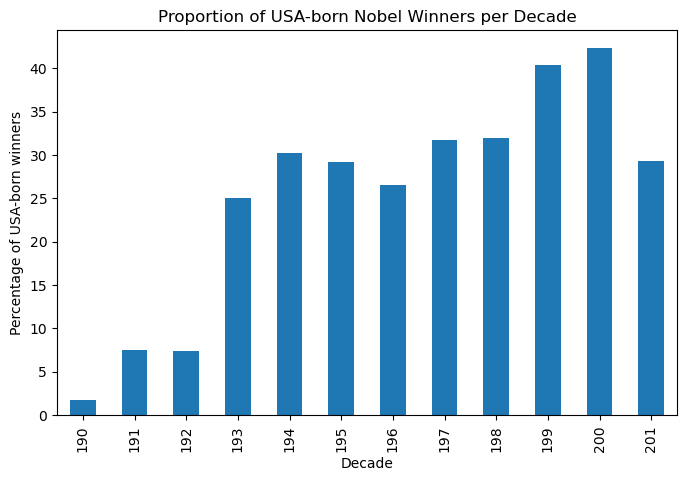

In [17]:
# Display the proportions of USA born winners per decade
# Display the proportions of USA born winners per decade
usa_prop_decade = nobel.groupby('decade')['usa_born_winner'].mean() * 100

usa_prop_decade.plot(kind='bar', figsize=(8,5))
plt.ylabel('Percentage of USA-born winners')
plt.xlabel('Decade')
plt.title('Proportion of USA-born Nobel Winners per Decade')
plt.show()

## 5. What is the gender of a typical Nobel Prize winner?
<p>So the USA became the dominating winner of the Nobel Prize first in the 1930s and had kept the leading position ever since. But one group that was in the lead from the start, and never seems to let go, are <em>men</em>. Maybe it shouldn't come as a shock that there is some imbalance between how many male and female prize winners there are, but how significant is this imbalance? And is it better or worse within specific prize categories like physics, medicine, literature, etc.?</p>

In [18]:
# Calculating the proportion of female laureates per decade w.r.t category
nobel['female_winner'] = nobel['sex']=='Female'

prop_female_winners = nobel.groupby(['decade','category_master'], as_index=False)['female_winner'].sum()


In [29]:
prop_female_winners

,decade,category_master,female_winner
0,190,1,0
1,190,3,1
2,190,4,0
3,190,5,1
4,190,6,1
...,...,...,...
61,201,2,0
62,201,3,2
63,201,4,2
64,201,5,4


In [19]:
nobel.pivot_table(index = 'decade', 
                  columns = 'category_master',
                  values = 'female_winner',
                  aggfunc = 'sum',
                  margins = True,
                  fill_value = 0)

category_master,1,2,3,4,5,6,All
decade,,,,,,,
190,0,0,1,0,1,1,3
191,1,0,0,0,0,0,1
192,0,0,2,0,0,0,2
193,1,0,1,0,1,0,3
194,0,0,1,1,1,0,3
195,0,0,0,0,0,0,0
196,1,0,1,0,0,1,3
197,0,0,0,1,3,0,4
198,0,0,0,3,1,0,4


As the category is numeric in nature, the picture looks incomplete. We do not know in which categories did they excel. We have a category master using which we can reprint the above data & make it look better. 

In [20]:
# import the category_master shared 
m_cat = pd.read_csv(r"C:\Users\statslab\Downloads\nobel_category_master.csv")

In [21]:
# merge the category master based on appropriate columns
print(nobel.shape)
nobel = pd.merge(nobel, m_cat, left_on = 'category_master', right_on = 'Category_master').drop(columns = 'Category_master')
print(nobel.shape)

(911, 21)
(911, 22)


In [22]:
# Calculating the proportion of female laureates per decade w.r.t. category_master for better interpretation
nobel.pivot_table(index = 'decade',
                  columns = 'category',
                  values = 'female_winner',
                  aggfunc ='sum',
                  margins = True,
                  dropna = False,
                  fill_value = 0
                 )

category,Chemistry,Economics,Literature,Medicine,Peace,Physics,All
decade,,,,,,,
190,0,0,1,0,1,1,3
191,1,0,0,0,0,0,1
192,0,0,2,0,0,0,2
193,1,0,1,0,1,0,3
194,0,0,1,1,1,0,3
195,0,0,0,0,0,0,0
196,1,0,1,0,0,1,3
197,0,0,0,1,3,0,4
198,0,0,0,3,1,0,4


## 6. The first woman to win the Nobel Prize
<p>The plot above is a bit messy as the lines are overplotting. But it does show some interesting trends and patterns. Overall the imbalance is pretty large with physics, economics, and chemistry having the largest imbalance. Medicine has a somewhat positive trend, and since the 1990s the literature prize is also now more balanced. The big outlier is the peace prize during the 2010s, but keep in mind that this just covers the years 2010 to 2016.</p>
<p>Given this imbalance, who was the first woman to receive a Nobel Prize? And in what category?</p>

In [23]:
# Picking out the first woman to win a Nobel Prize
nobel.sort_values('year', inplace = True)

In [24]:
nobel[nobel['sex'] == 'Female'][['year','decade', 'sex', 'category', 'full_name', 'birth_country']].head(1)

,year,decade,sex,category,full_name,birth_country
19,1903,190,Female,Physics,"Marie Curie, nÃ©e Sklodowska",Russian Empire (Poland)


In [25]:
nobel[nobel.sex == 'Female'].nsmallest(1, 'year')

,ID,year,category_master,prize,prize_share,laureate_id,laureate_type,organization_name,organization_city,organization_country,...,birth_city,birth_country,sex,death_date,death_city,death_country,decade,usa_born_winner,female_winner,category
19,19036,1903,6,The Nobel Prize in Physics 1903,"44,287",6,Individual,NaN,NaN,NaN,...,Warsaw,Russian Empire (Poland),Female,1934-07-04,Sallanches,France,190,False,True,Physics


## 7. Repeat laureates
<p>For most scientists/writers/activists a Nobel Prize would be the crowning achievement of a long career. But for some people, one is just not enough, and few have gotten it more than once. Who are these lucky few? (Having won no Nobel Prize myself, I'll assume it's just about luck.)</p>

In [26]:
# Selecting the laureates that have received 2 or more prizes.
t = nobel.groupby('laureate_id', as_index = False)['ID'].count()

In [27]:
t.rename(columns = {'ID':'total_nobels'}, inplace = True)
t.head()

,laureate_id,total_nobels
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [28]:
nobel = pd.merge(nobel, t, on='laureate_id')

In [29]:
nobel.loc[ nobel.total_nobels > 1 , ['year', 'full_name', 'category', 'sex', 'birth_country']]

,year,full_name,category,sex,birth_country
13,1903,"Marie Curie, nÃ©e Sklodowska",Physics,Female,Russian Empire (Poland)
62,1911,"Marie Curie, nÃ©e Sklodowska",Chemistry,Female,Russian Empire (Poland)
88,1917,ComitÃ© international de la Croix Rouge (Inter...,Peace,NaN,NaN
212,1944,ComitÃ© international de la Croix Rouge (Inter...,Peace,NaN,NaN
280,1954,Office of the United Nations High Commissioner...,Peace,NaN,NaN
281,1954,Linus Carl Pauling,Chemistry,Male,United States of America
291,1956,John Bardeen,Physics,Male,United States of America
313,1958,Frederick Sanger,Chemistry,Male,United Kingdom
337,1962,Linus Carl Pauling,Peace,Male,United States of America
346,1963,ComitÃ© international de la Croix Rouge (Inter...,Peace,NaN,NaN


In [30]:
nobel.groupby('full_name').filter( lambda x : len(x)> 1)

,ID,year,category_master,prize,prize_share,laureate_id,laureate_type,organization_name,organization_city,organization_country,...,birth_country,sex,death_date,death_city,death_country,decade,usa_born_winner,female_winner,category,total_nobels
13,19036,1903,6,The Nobel Prize in Physics 1903,"44,287",6,Individual,NaN,NaN,NaN,...,Russian Empire (Poland),Female,1934-07-04,Sallanches,France,190,False,True,Physics,2
62,19111,1911,1,The Nobel Prize in Chemistry 1911,"44,197",6,Individual,Sorbonne University,Paris,France,...,Russian Empire (Poland),Female,1934-07-04,Sallanches,France,191,False,True,Chemistry,2
88,19175,1917,5,The Nobel Peace Prize 1917,"44,197",482,Organization,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,191,False,False,Peace,3
212,19445,1944,5,The Nobel Peace Prize 1944,"44,197",482,Organization,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,194,False,False,Peace,3
280,19545,1954,5,The Nobel Peace Prize 1954,"44,197",515,Organization,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,195,False,False,Peace,2
281,19541,1954,1,The Nobel Prize in Chemistry 1954,"44,197",217,Individual,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,...,United States of America,Male,1994-08-19,"Big Sur, CA",United States of America,195,True,False,Chemistry,2
291,19566,1956,6,The Nobel Prize in Physics 1956,"44,256",66,Individual,University of Illinois,"Urbana, IL",United States of America,...,United States of America,Male,1991-01-30,"Boston, MA",United States of America,195,True,False,Physics,2
313,19581,1958,1,The Nobel Prize in Chemistry 1958,"44,197",222,Individual,University of Cambridge,Cambridge,United Kingdom,...,United Kingdom,Male,2013-11-19,Cambridge,United Kingdom,195,False,False,Chemistry,2
337,19625,1962,5,The Nobel Peace Prize 1962,"44,197",217,Individual,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,...,United States of America,Male,1994-08-19,"Big Sur, CA",United States of America,196,True,False,Peace,2
346,19635,1963,5,The Nobel Peace Prize 1963,"44,228",482,Organization,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,196,False,False,Peace,3


## 8. How old are you when you get the prize?
<p>The list of repeat winners contains some illustrious names! We again meet Marie Curie, who got the prize in physics for discovering radiation and in chemistry for isolating radium and polonium. John Bardeen got it twice in physics for transistors and superconductivity, Frederick Sanger got it twice in chemistry, and Linus Carl Pauling got it first in chemistry and later in peace for his work in promoting nuclear disarmament. We also learn that organizations also get the prize as both the Red Cross and the UNHCR have gotten it twice.</p>
<p>But how old are you generally when you get the prize?</p>

In [31]:
# Check the data type of all columns 
nobel.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    911 non-null    int64         
 1   year                  911 non-null    int64         
 2   category_master       911 non-null    int64         
 3   prize                 911 non-null    object        
 4   prize_share           911 non-null    object        
 5   laureate_id           911 non-null    int64         
 6   laureate_type         911 non-null    object        
 7   organization_name     665 non-null    object        
 8   organization_city     667 non-null    object        
 9   organization_country  667 non-null    object        
 10  full_name             911 non-null    object        
 11  birth_date            883 non-null    object        
 12  birth_city            883 non-null    object        
 13  birth_country       

In [32]:
# Converting birth_date from String to datetime
nobel['birth_date'] = pd.to_datetime(nobel['birth_date'])

In [33]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    911 non-null    int64         
 1   year                  911 non-null    int64         
 2   category_master       911 non-null    int64         
 3   prize                 911 non-null    object        
 4   prize_share           911 non-null    object        
 5   laureate_id           911 non-null    int64         
 6   laureate_type         911 non-null    object        
 7   organization_name     665 non-null    object        
 8   organization_city     667 non-null    object        
 9   organization_country  667 non-null    object        
 10  full_name             911 non-null    object        
 11  birth_date            883 non-null    datetime64[ns]
 12  birth_city            883 non-null    object        
 13  birth_country       

In [34]:
nobel['birth_date'].head()

0   1852-08-30
1   1839-03-16
2   1854-03-15
3   1828-05-08
4   1822-05-20
Name: birth_date, dtype: datetime64[ns]

In [35]:
nobel['birth_date'].dt.year

0      1852.0
1      1839.0
2      1854.0
3      1828.0
4      1822.0
        ...  
906    1951.0
907    1942.0
908    1944.0
909    1949.0
910    1943.0
Name: birth_date, Length: 911, dtype: float64

In [36]:
# Calculating the age of Nobel Prize winners
nobel['age'] = nobel['year'] - nobel['birth_date'].dt.year

nobel[['year', 'birth_date', 'age']].head()

,year,birth_date,age
0,1901,1852-08-30,49.0
1,1901,1839-03-16,62.0
2,1901,1854-03-15,47.0
3,1901,1828-05-08,73.0
4,1901,1822-05-20,79.0


In [37]:
nobel.age.mean()

59.453001132502834

In [38]:
nobel.age.mode()

0    61.0
Name: age, dtype: float64

In [39]:
nobel.age.median()

60.0

## 9. How old were they, when they got their first & second prize ?
<p>Clearly a few individuals have been so good that they received nobel prize twice. Can we see ? what was their age at first & second adajecent to each other ? Let us also see, at what age did they passed away (if so )

In [40]:
# Converting death_date from String to datetime
pd.pivot_table( nobel[ (nobel['total_nobels'] > 1) & (nobel['laureate_type'] == 'Individual') ][['full_name', 'category', 'age']] ,
                index = 'full_name',
                aggfunc = ['min', 'max'],
                values = 'age',
                dropna = False,
                fill_value = 0,
                margins = True
                )

,min,max
,age,age
full_name,,
Frederick Sanger,40.0,62.0
John Bardeen,48.0,64.0
Linus Carl Pauling,53.0,61.0
"Marie Curie, nÃ©e Sklodowska",36.0,44.0
All,36.0,64.0


In [41]:
# Calculating the age of death of Nobel Prize winners
# Calculating the age of death of Nobel Prize winners
nobel['birth_date'] = pd.to_datetime(nobel['birth_date'], errors='coerce')
nobel['death_date'] = pd.to_datetime(nobel['death_date'], errors='coerce')

nobel['age_at_death'] = (nobel['death_date'] - nobel['birth_date']).dt.days / 365.25

nobel[['full_name', 'age_at_death']].dropna().head()


,full_name,age_at_death
0,Jacobus Henricus van 't Hoff,58.496920
1,Sully Prudhomme,68.476386
2,Emil Adolf von Behring,63.041752
3,Jean Henry Dunant,82.475017
4,FrÃ©dÃ©ric Passy,90.061602


In [42]:
# Identify the first & second age when they won the prize & also the age at the time of death
nobel_sorted = nobel.sort_values(['full_name', 'age'])
age_summary = (
    nobel_sorted
    .groupby('full_name')
    .agg(
        first_win_age=('age', 'min'),
        second_win_age=('age', lambda x: x.nsmallest(2).iloc[-1] if len(x) > 1 else None),
        age_at_death=('age_at_death', 'first')
    )
)

age_summary


,first_win_age,second_win_age,age_at_death
full_name,,,
A. Michael Spence,58.0,NaN,NaN
Aage Niels Bohr,53.0,NaN,87.222450
Aaron Ciechanover,57.0,NaN,NaN
Aaron Klug,56.0,NaN,NaN
Abdus Salam,53.0,NaN,70.811773
...,...,...,...
Youyou Tu,85.0,NaN,NaN
Yuan T. Lee,50.0,NaN,NaN
Yves Chauvin,75.0,NaN,84.298426


#### The analysis shows that multiple-time Nobel Prize winners typically received their first award in mid-adulthood, with subsequent awards occurring later in life, while their ages at death indicate long academic and scientific careers.

## 10. Oldest and youngest winners
<p>More plots with lots of exciting stuff going on! We see that both winners of the chemistry, medicine, and physics prize have gotten older over time. The trend is strongest for physics: the average age used to be below 50, and now it's almost 70. Literature and economics are more stable. We also see that economics is a newer category. But peace shows an opposite trend where winners are getting younger! </p>
<p>In the peace category we also a winner around 2010 that seems exceptionally young. This begs the questions, who are the oldest and youngest people ever to have won a Nobel Prize?</p>

In [43]:
# The youngest winner of a Nobel Prize as of 2016
display( nobel.sort_values('age')[['full_name', 'age']].head(1) )

# The oldest winner of a Nobel Prize as of 2016
display( nobel.sort_values('age', ascending = False)[['full_name', 'age']].head(1))


,full_name,age
878,Malala Yousafzai,17.0


,full_name,age
802,Leonid Hurwicz,90.0


In [44]:
display(nobel[['age', 'full_name', 'category', 'sex']].nlargest(1,'age'))

,age,full_name,category,sex
802,90.0,Leonid Hurwicz,Economics,Male


## 11. Winners from my country - India
<p> We do not have citizenship in our data, but using what is available. Let us identify nobel prize winners from India. A psuedo measure could be, birth_country & death_country.
    Sometimes there is data limitation, and we can see how it can affect analysis.


In [45]:
# Identify the rows where birth country is India

nobel.loc[ nobel['birth_country'] == 'India' , ['full_name', 'category', 'age', 'year', 'birth_country', 'death_country'] ]


,full_name,category,age,year,birth_country,death_country
8,Ronald Ross,Medicine,45.0,1902,India,United Kingdom
77,Rabindranath Tagore,Literature,52.0,1913,India,India
151,Sir Chandrasekhara Venkata Raman,Physics,42.0,1930,India,India
386,Har Gobind Khorana,Medicine,46.0,1968,India,United States of America
695,Amartya Sen,Economics,65.0,1998,India,NaN
828,Venkatraman Ramakrishnan,Chemistry,NaN,2009,India,NaN
879,Kailash Satyarthi,Peace,60.0,2014,India,NaN


In [46]:
# Identify the rows where birth country or death country is India

nobel.loc[ (nobel['birth_country'] == 'India') | (nobel['death_country'] == 'India') , 
          ['full_name', 'category', 'age', 'year', 'birth_country', 'death_country'] ]


,full_name,category,age,year,birth_country,death_country
8,Ronald Ross,Medicine,45.0,1902,India,United Kingdom
77,Rabindranath Tagore,Literature,52.0,1913,India,India
151,Sir Chandrasekhara Venkata Raman,Physics,42.0,1930,India,India
386,Har Gobind Khorana,Medicine,46.0,1968,India,United States of America
497,Mother Teresa,Peace,69.0,1979,Ottoman Empire (Republic of Macedonia),India
695,Amartya Sen,Economics,65.0,1998,India,NaN
828,Venkatraman Ramakrishnan,Chemistry,NaN,2009,India,NaN
879,Kailash Satyarthi,Peace,60.0,2014,India,NaN


In [47]:
# Inspect the rows of the year 1983
nobel[nobel['year'] == 1983][['full_name', 'category', 'age', 'year', 'birth_country', 'death_country']]


,full_name,category,age,year,birth_country,death_country
536,Subramanyan Chandrasekhar,Physics,73.0,1983,India (Pakistan),United States of America
537,William Alfred Fowler,Physics,72.0,1983,United States of America,United States of America
538,Lech Walesa,Peace,40.0,1983,Poland,NaN
539,Gerard Debreu,Economics,62.0,1983,France,France
540,William Golding,Literature,72.0,1983,United Kingdom,United Kingdom
541,Barbara McClintock,Medicine,81.0,1983,United States of America,United States of America
542,Henry Taube,Chemistry,68.0,1983,Canada,United States of America


In [50]:
nobel['country_india'] = nobel['birth_country'].str.find('India')

In [51]:
nobel[['full_name', 'category', 'age', 'year', 'birth_country', 'death_country','country_india']].head(10)

,full_name,category,age,year,birth_country,death_country,country_india
0,Jacobus Henricus van 't Hoff,Chemistry,49.0,1901,Netherlands,Germany,-1.0
1,Sully Prudhomme,Literature,62.0,1901,France,France,-1.0
2,Emil Adolf von Behring,Medicine,47.0,1901,Prussia (Poland),Germany,-1.0
3,Jean Henry Dunant,Peace,73.0,1901,Switzerland,Switzerland,-1.0
4,FrÃ©dÃ©ric Passy,Peace,79.0,1901,France,France,-1.0
5,Wilhelm Conrad RÃ¶ntgen,Physics,56.0,1901,Prussia (Germany),Germany,-1.0
6,Hermann Emil Fischer,Chemistry,50.0,1902,Prussia (Germany),Germany,-1.0
7,Christian Matthias Theodor Mommsen,Literature,85.0,1902,Schleswig (Germany),Germany,-1.0
8,Ronald Ross,Medicine,45.0,1902,India,United Kingdom,0.0
9,Ã‰lie Ducommun,Peace,69.0,1902,Switzerland,Switzerland,-1.0


In [52]:
nobel.loc[ nobel.country_india >-1 ,['full_name', 'category', 'age', 'year', 'birth_country', 'death_country','country_india']].head(10)

,full_name,category,age,year,birth_country,death_country,country_india
8,Ronald Ross,Medicine,45.0,1902,India,United Kingdom,0.0
41,Rudyard Kipling,Literature,42.0,1907,British India (India),United Kingdom,8.0
77,Rabindranath Tagore,Literature,52.0,1913,India,India,0.0
151,Sir Chandrasekhara Venkata Raman,Physics,42.0,1930,India,India,0.0
386,Har Gobind Khorana,Medicine,46.0,1968,India,United States of America,0.0
495,Abdus Salam,Physics,53.0,1979,India (Pakistan),United Kingdom,0.0
536,Subramanyan Chandrasekhar,Physics,73.0,1983,India (Pakistan),United States of America,0.0
695,Amartya Sen,Economics,65.0,1998,India,NaN,0.0
786,Muhammad Yunus,Peace,66.0,2006,British India (Bangladesh),NaN,8.0
828,Venkatraman Ramakrishnan,Chemistry,NaN,2009,India,NaN,0.0
